# EDA [exploratory data analysis]

(891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842 

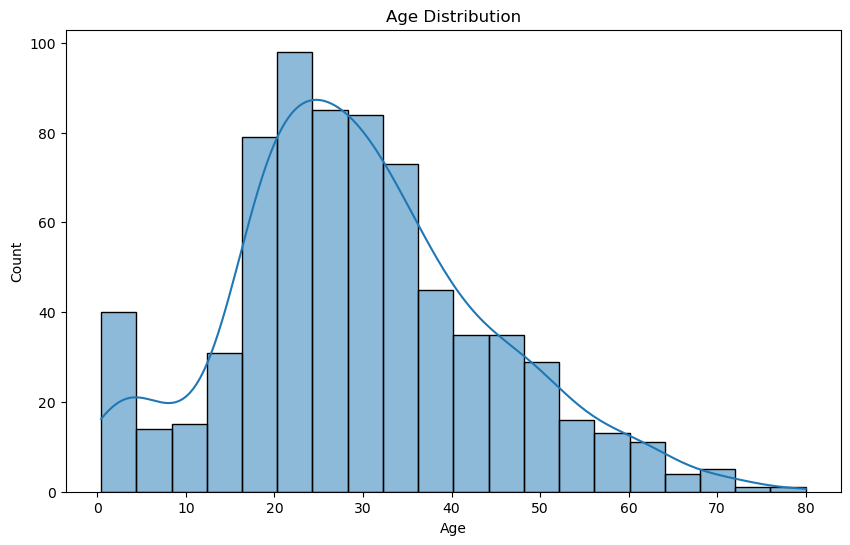

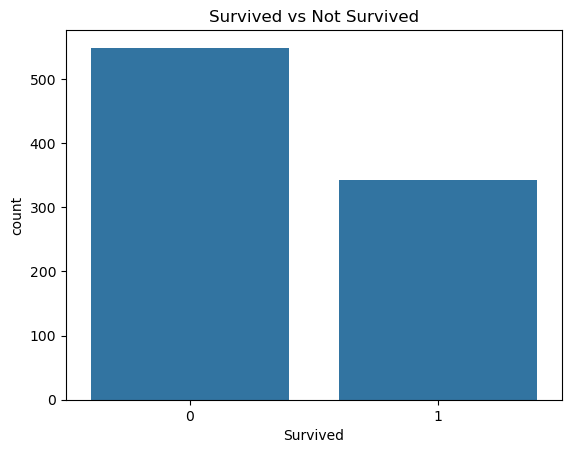

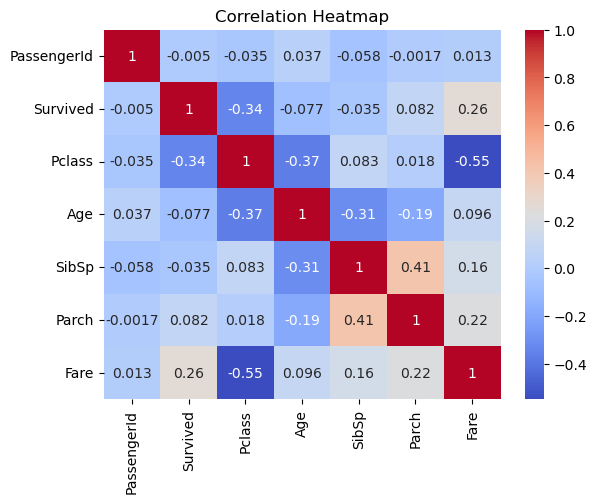

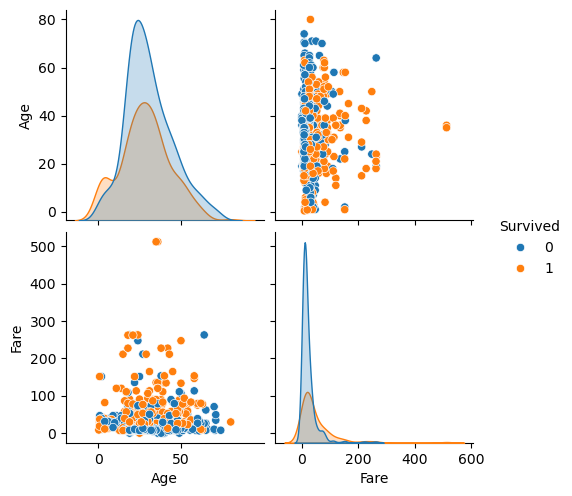

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('train.csv')   

print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())        

plt.figure(figsize=(10,6))
sns.histplot(df['Age'], kde=True)         
plt.title('Age Distribution')
plt.show()

sns.countplot(x='Survived', data=df)       
plt.title('Survived vs Not Survived')
plt.show()

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

sns.pairplot(df[['Age', 'Fare', 'Survived']], hue='Survived')
plt.show()

# Feature Engineering

In [3]:

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
df = df.drop(['Cabin', 'Ticket', 'Name'], axis=1)   

df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[['Age', 'Fare']] = scaler.fit_transform(df[['Age', 'Fare']])

print(df.head())
print(df.info())   

   PassengerId  Survived  Pclass       Age  SibSp  Parch      Fare  Sex_male  \
0            1         0       3 -0.565736      1      0 -0.502445      True   
1            2         1       1  0.663861      1      0  0.786845     False   
2            3         1       3 -0.258337      0      0 -0.488854     False   
3            4         1       1  0.433312      1      0  0.420730     False   
4            5         0       3  0.433312      0      0 -0.486337      True   

   Embarked_Q  Embarked_S  
0       False        True  
1       False       False  
2       False        True  
3       False        True  
4       False        True  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Age          891 non-null    fl